In [1]:
!nvidia-smi

Sun Jun 29 14:43:39 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Install YOLOv8

YOLOv8 can be installed in two ways - from the source and via pip. This is because it is the first iteration of YOLO to have an official package.

In [ ]:


!pip install ultralytics==8.2.103 -q

from IPython import display
display.clear_output()


!yolo settings sync=False

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.2.103 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.9/112.6 GB disk)


In [4]:
from ultralytics import YOLO

from IPython.display import display, Image

## Inference with Pre-trained COCO Model

### 💻 CLI

In [5]:
%cd {HOME}
!yolo task=detect mode=predict model=yolov8n.pt conf=0.25 source='https://media.roboflow.com/notebooks/examples/dog.jpeg' save=True

/content
100% 6.25M/6.25M [00:00<00:00, 81.6MB/s]
Ultralytics YOLOv8.2.103 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n summary (fused): 168 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

100% 104k/104k [00:00<00:00, 64.3MB/s]
image 1/1 /content/dog.jpeg: 640x384 1 person, 1 car, 1 dog, 40.5ms
Speed: 11.1ms preprocess, 40.5ms inference, 336.7ms postprocess per image at shape (1, 3, 640, 384)
Results saved to runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


/content


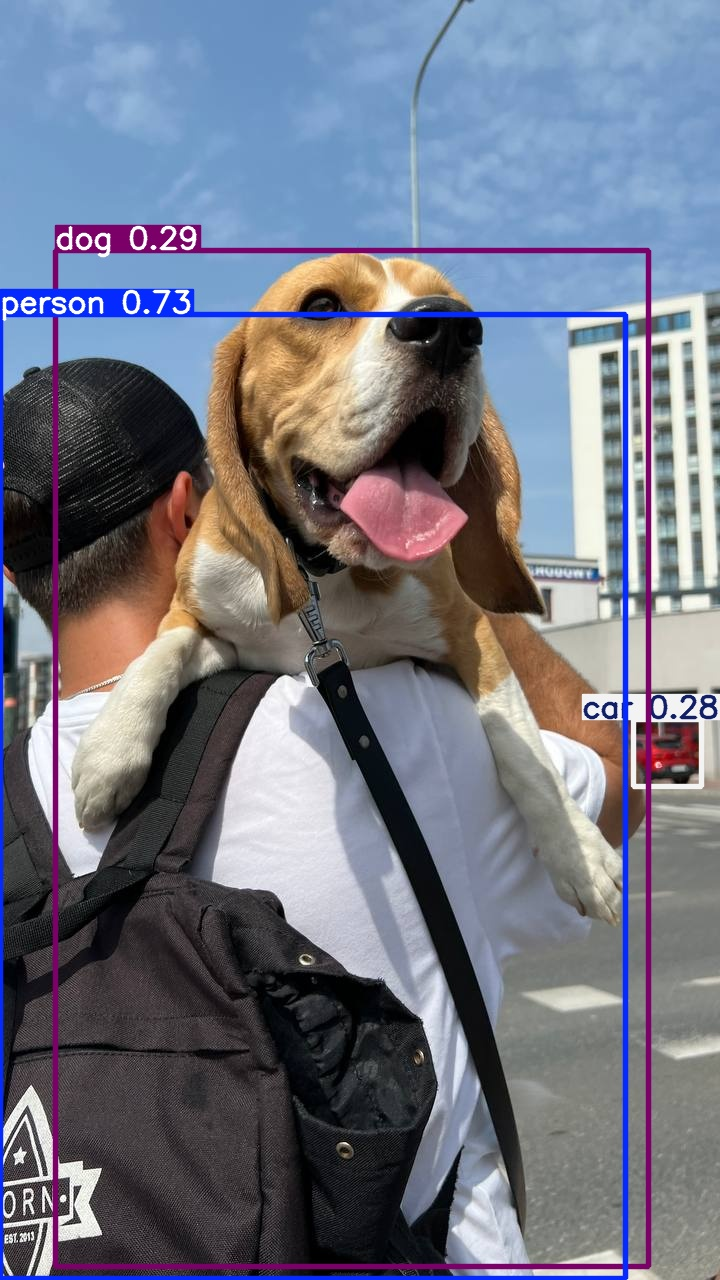

In [6]:
%cd {HOME}
Image(filename='runs/detect/predict/dog.jpeg', height=600)

In [ ]:
!mkdir -p {HOME}/datasets
%cd {HOME}/datasets

!pip install roboflow==1.1.48 --quiet

import roboflow

!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="")
project = rf.workspace("my-project-v8dgb").project("my-first-project-nt4s6")
version = project.version(3)
dataset = version.download("yolov5")





/content/datasets
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 14.2 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to My-First-Project-3 in yolov5pytorch:: 100%|██████████| 126/126 [00:00<00:00, 4288.93it/s]


In [8]:
!cat {HOME}/datasets/My-First-Project-3/data.yaml


names:
- bolt
- screws
nc: 2
roboflow:
  license: CC BY 4.0
  project: my-first-project-nt4s6
  url: https://universe.roboflow.com/my-project-v8dgb/my-first-project-nt4s6/dataset/3
  version: 3
  workspace: my-project-v8dgb
test: ../test/images
train: My-First-Project-3/train/images
val: My-First-Project-3/valid/images


In [9]:
print(dataset.location)


/content/datasets/My-First-Project-3


In [10]:
!apt-get install tree


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tree
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 47.9 kB of archives.
After this operation, 116 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tree amd64 2.0.2-1 [47.9 kB]
Fetched 47.9 kB in 1s (81.1 kB/s)
Selecting previously unselected package tree.
(Reading database ... 126308 files and directories currently installed.)
Preparing to unpack .../tree_2.0.2-1_amd64.deb ...
Unpacking tree (2.0.2-1) ...
Setting up tree (2.0.2-1) ...
Processing triggers for man-db (2.10.2-1) ...


In [11]:
!tree {dataset.location}


/content/datasets/My-First-Project-3
├── data.yaml
├── README.dataset.txt
├── README.roboflow.txt
├── test
│   ├── images
│   │   ├── 20240713_192951_jpg.rf.7f0135cef9a1b5e5c346b8f96ea91654.jpg
│   │   ├── 20240713_193135_jpg.rf.5c47d3d4ee853faed529a895bb84eeb0.jpg
│   │   ├── 20240713_193659_jpg.rf.02a0177702c96c7f38d1028732e57356.jpg
│   │   ├── img2_jpg.rf.ffe9424466766a75e29f42b4f01618a5.jpg
│   │   └── img3_jpg.rf.b5f300570127bea33e1285556b146163.jpg
│   └── labels
│       ├── 20240713_192951_jpg.rf.7f0135cef9a1b5e5c346b8f96ea91654.txt
│       ├── 20240713_193135_jpg.rf.5c47d3d4ee853faed529a895bb84eeb0.txt
│       ├── 20240713_193659_jpg.rf.02a0177702c96c7f38d1028732e57356.txt
│       ├── img2_jpg.rf.ffe9424466766a75e29f42b4f01618a5.txt
│       └── img3_jpg.rf.b5f300570127bea33e1285556b146163.txt
├── train
│   ├── images
│   │   ├── 20240713_193650_jpg.rf.08e425c1f33801a55a47bb32915f3168.jpg
│   │   ├── 20240713_193650_jpg.rf.0cbcdf3d1bb4357374b726f9369f7d1a.jpg
│   │   ├── 202407

In [12]:
!cat /content/datasets/My-First-Project-3/data.yaml


names:
- bolt
- screws
nc: 2
roboflow:
  license: CC BY 4.0
  project: my-first-project-nt4s6
  url: https://universe.roboflow.com/my-project-v8dgb/my-first-project-nt4s6/dataset/3
  version: 3
  workspace: my-project-v8dgb
test: ../test/images
train: My-First-Project-3/train/images
val: My-First-Project-3/valid/images


## Custom Training

In [15]:


%cd {HOME}
!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml epochs=25 imgsz=640 plots=True


/content
New https://pypi.org/project/ultralytics/8.3.160 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/datasets/My-First-Project-3/data.yaml, epochs=25, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False,

/content


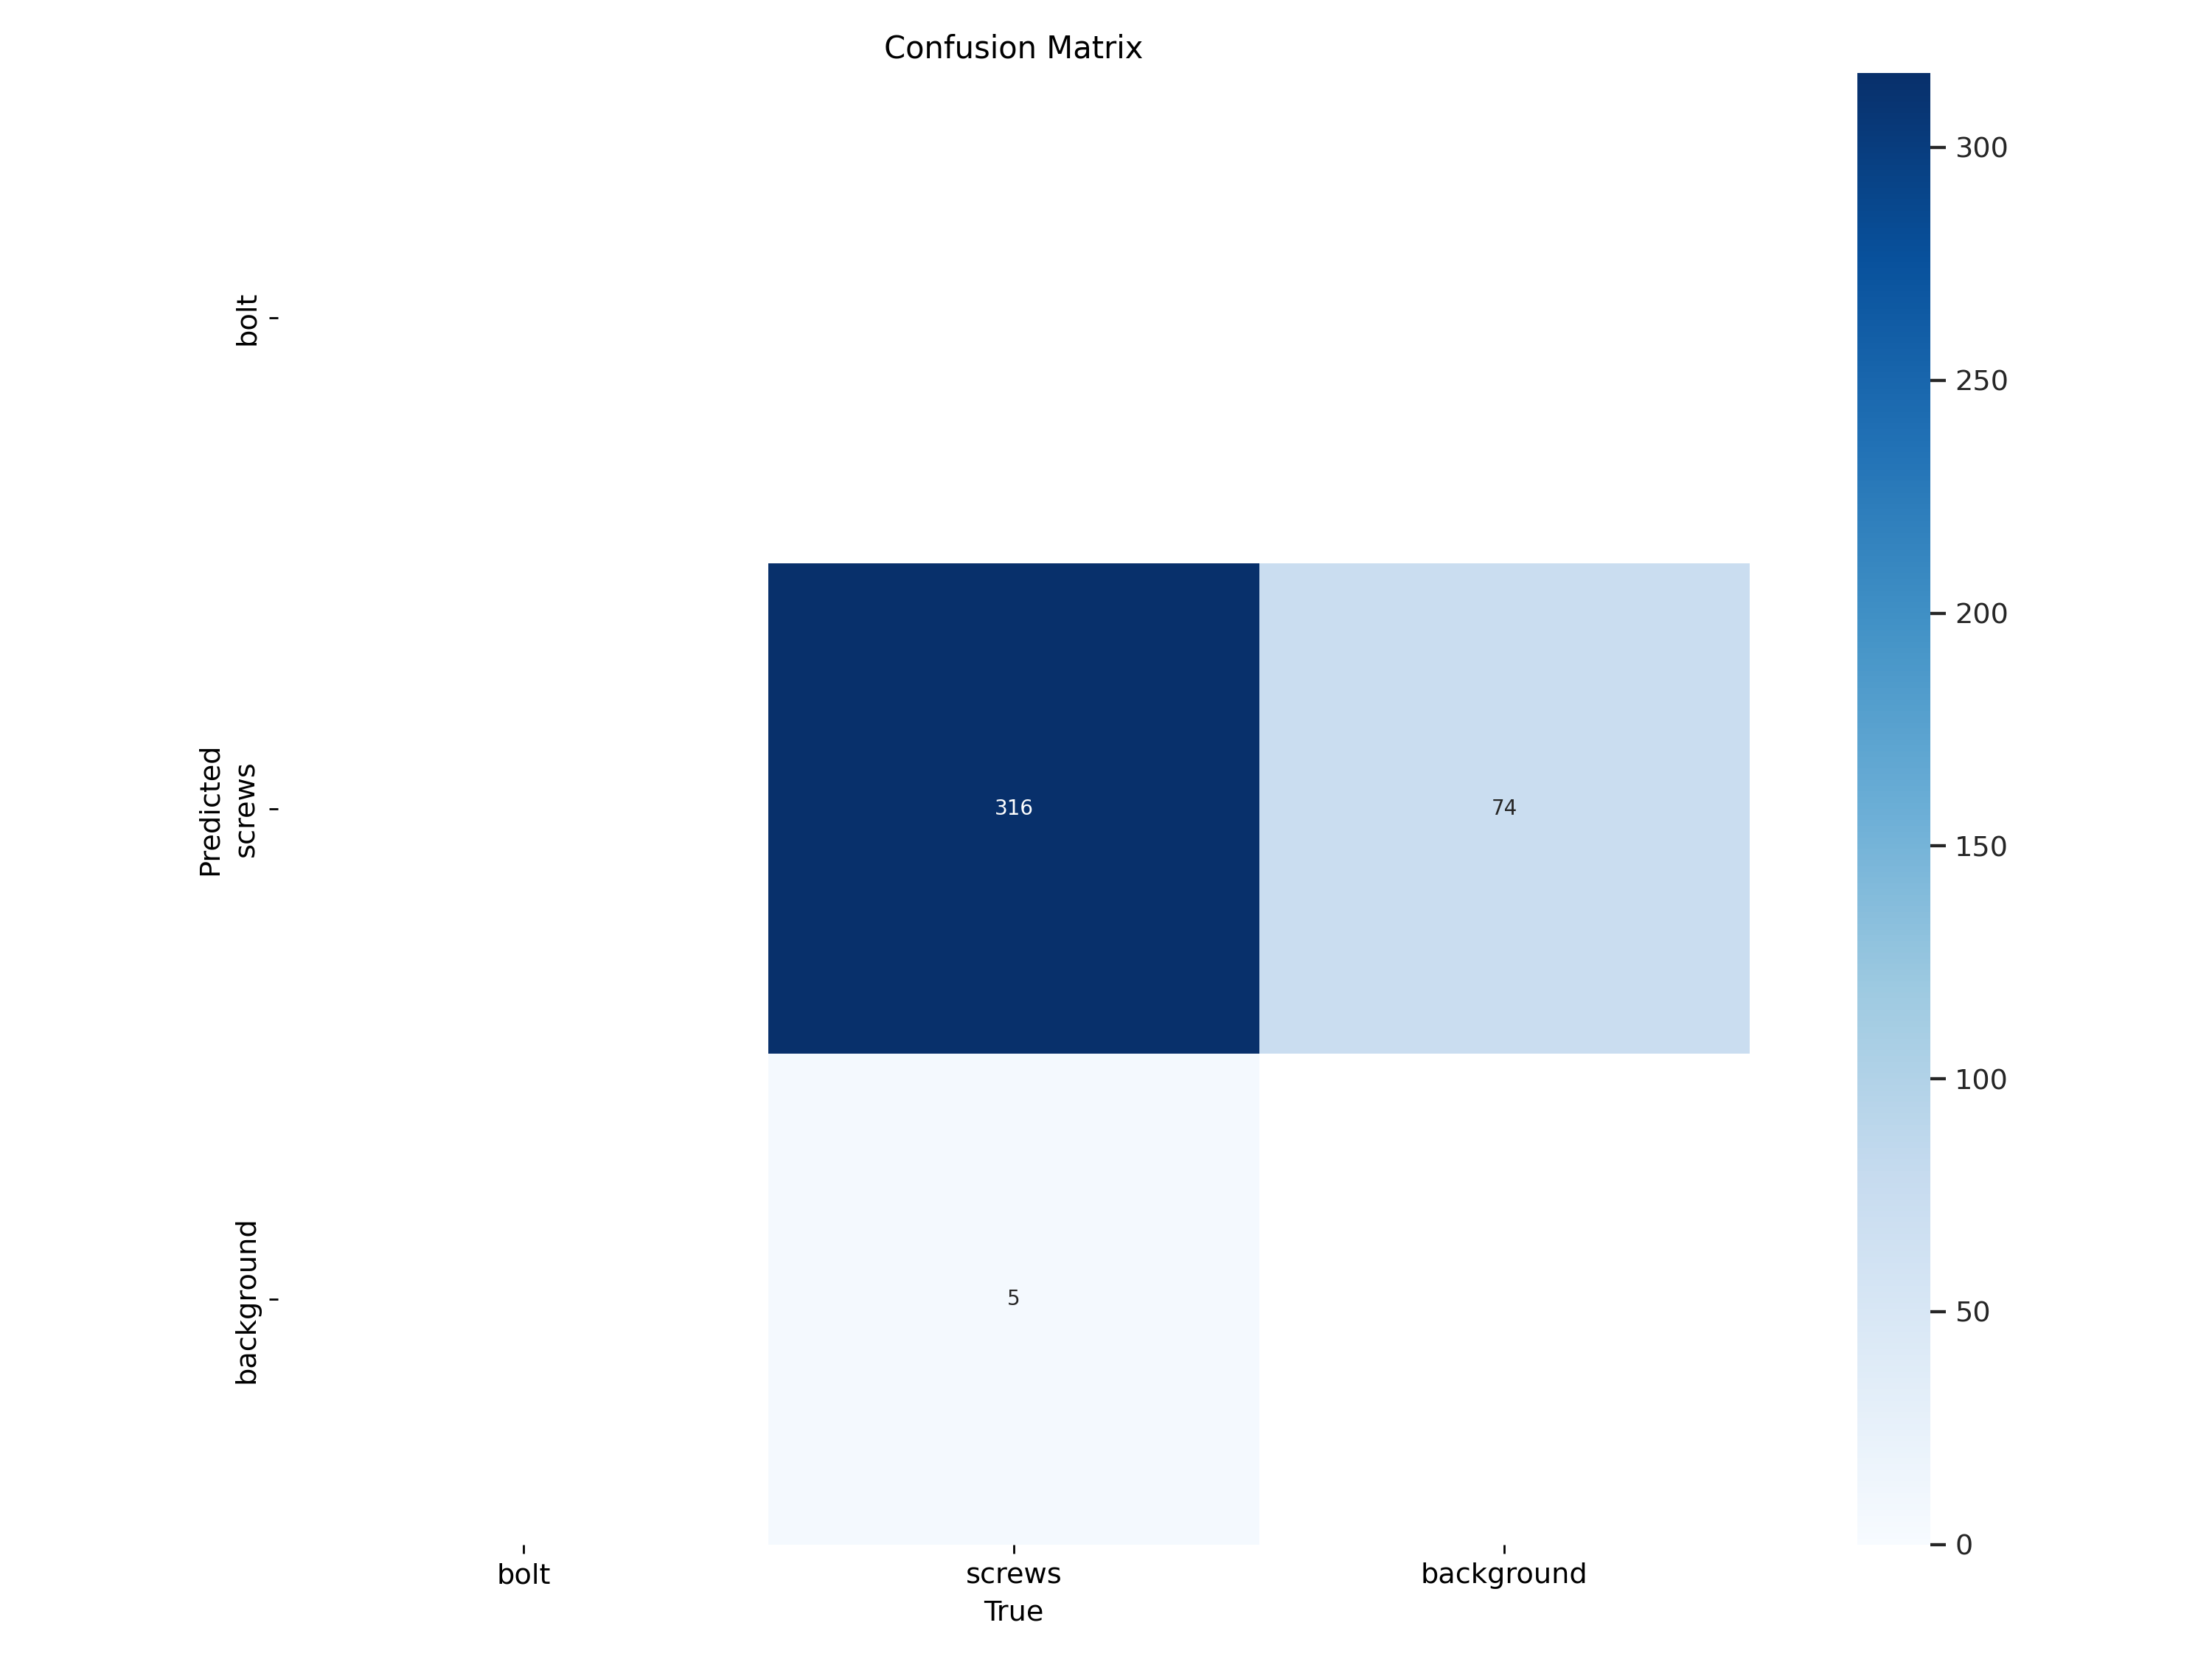

In [16]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train2/confusion_matrix.png', width=600)

/content


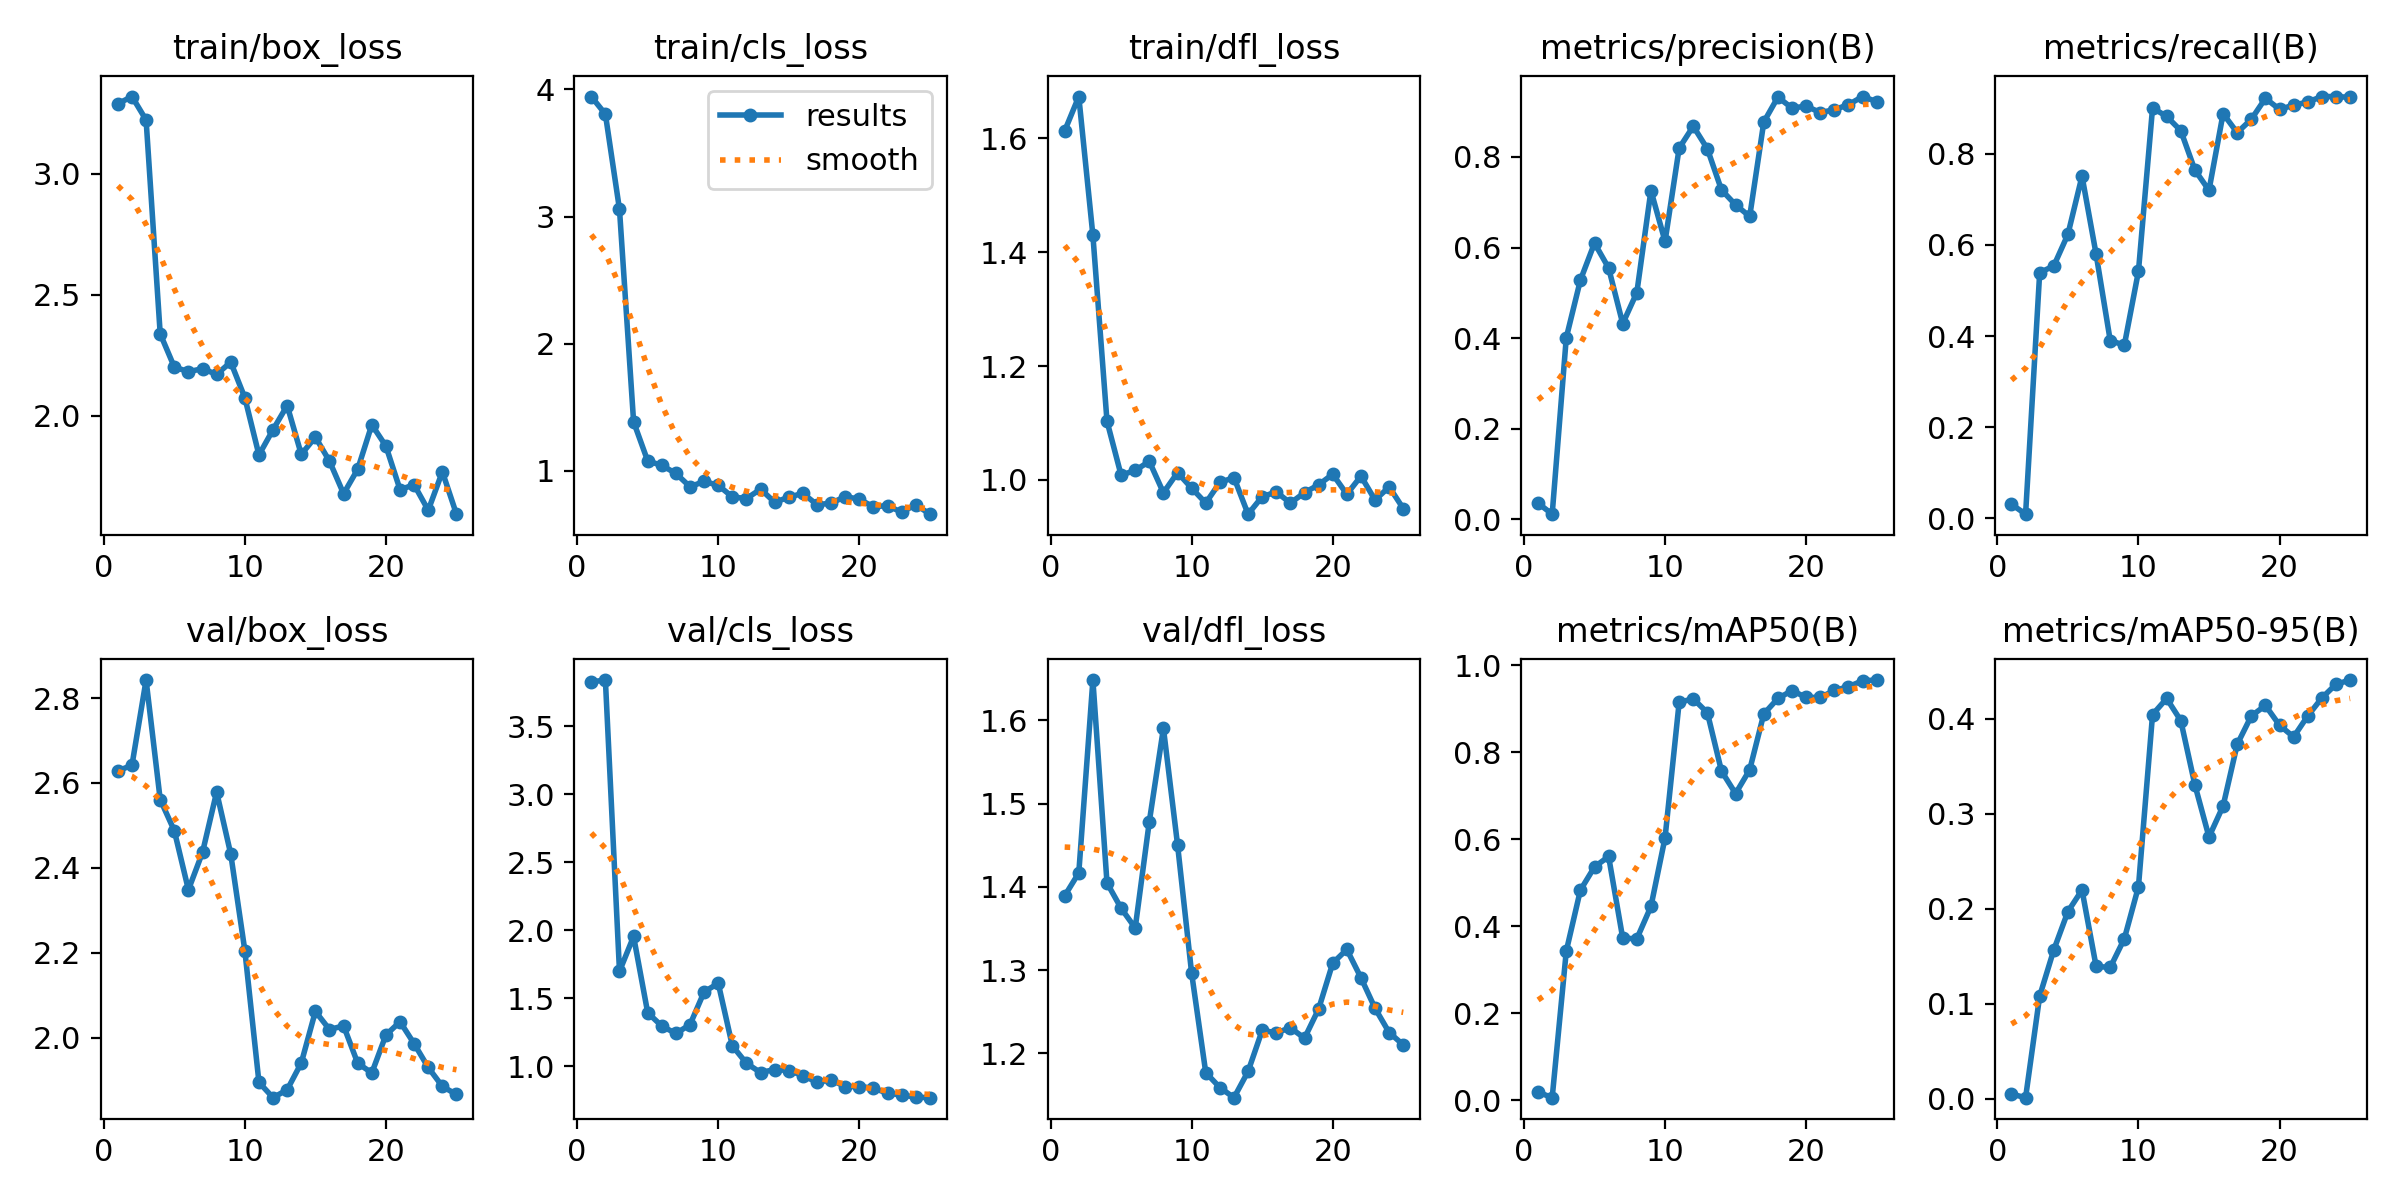

In [18]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train2/results.png', width=600)

/content


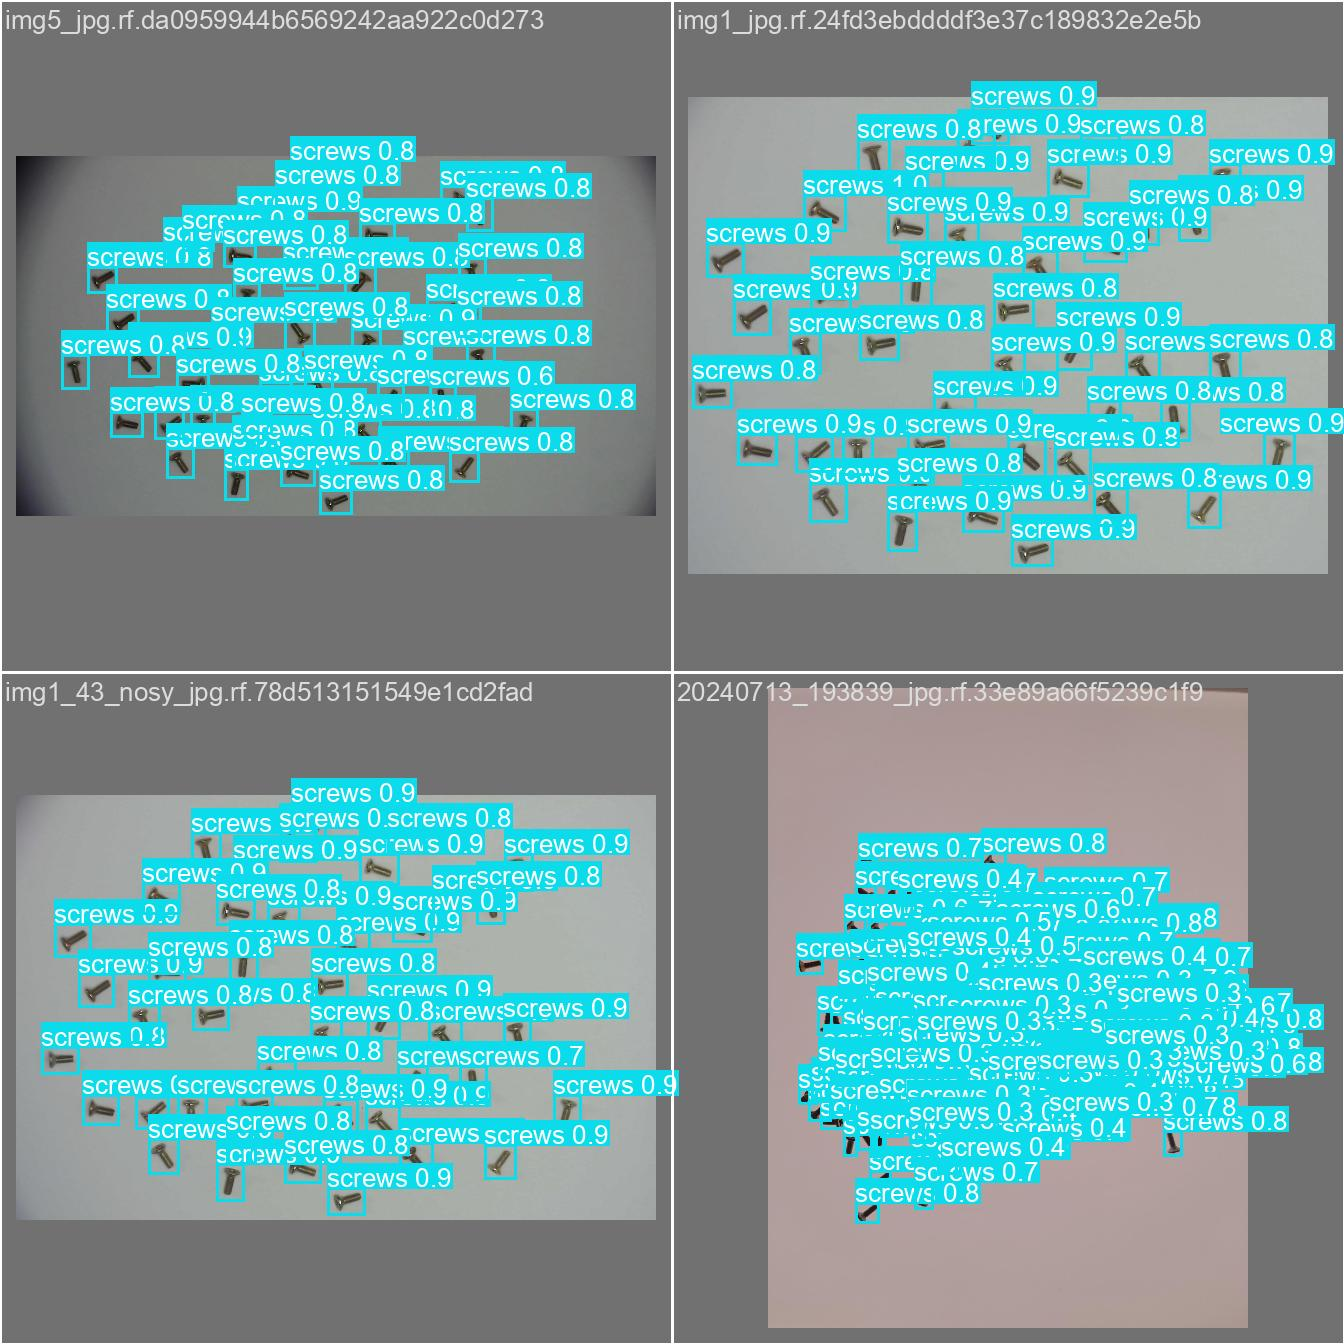

In [19]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train2/val_batch0_pred.jpg', width=600)


## Validate Custom Model

In [21]:

%cd {HOME}

!yolo task=detect \
    mode=predict \
    model={HOME}/runs/detect/train2/weights/best.pt \
    conf=0.25 \
    source={dataset.location}/test/images \
    save=True \
    save_txt=True


/content
Ultralytics YOLOv8.2.103 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 168 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs

image 1/5 /content/datasets/My-First-Project-3/test/images/20240713_192951_jpg.rf.7f0135cef9a1b5e5c346b8f96ea91654.jpg: 640x480 66 screwss, 36.7ms
image 2/5 /content/datasets/My-First-Project-3/test/images/20240713_193135_jpg.rf.5c47d3d4ee853faed529a895bb84eeb0.jpg: 640x512 65 screwss, 38.1ms
image 3/5 /content/datasets/My-First-Project-3/test/images/20240713_193659_jpg.rf.02a0177702c96c7f38d1028732e57356.jpg: 640x512 10 screwss, 12.1ms
image 4/5 /content/datasets/My-First-Project-3/test/images/img2_jpg.rf.ffe9424466766a75e29f42b4f01618a5.jpg: 512x640 43 screwss, 50.7ms
image 5/5 /content/datasets/My-First-Project-3/test/images/img3_jpg.rf.b5f300570127bea33e1285556b146163.jpg: 384x640 43 screwss, 37.9ms
Speed: 3.0ms preprocess, 35.1ms inference, 27.9ms postprocess per image at shape (1, 3, 384, 640)
Results 

## Inference with Custom Model

In [22]:
%cd {HOME}
!yolo task=detect mode=predict model={HOME}/runs/detect/train2/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

/content
Ultralytics YOLOv8.2.103 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 168 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs

image 1/5 /content/datasets/My-First-Project-3/test/images/20240713_192951_jpg.rf.7f0135cef9a1b5e5c346b8f96ea91654.jpg: 640x480 66 screwss, 36.3ms
image 2/5 /content/datasets/My-First-Project-3/test/images/20240713_193135_jpg.rf.5c47d3d4ee853faed529a895bb84eeb0.jpg: 640x512 65 screwss, 37.3ms
image 3/5 /content/datasets/My-First-Project-3/test/images/20240713_193659_jpg.rf.02a0177702c96c7f38d1028732e57356.jpg: 640x512 10 screwss, 12.1ms
image 4/5 /content/datasets/My-First-Project-3/test/images/img2_jpg.rf.ffe9424466766a75e29f42b4f01618a5.jpg: 512x640 43 screwss, 37.6ms
image 5/5 /content/datasets/My-First-Project-3/test/images/img3_jpg.rf.b5f300570127bea33e1285556b146163.jpg: 384x640 43 screwss, 36.8ms
Speed: 3.0ms preprocess, 32.0ms inference, 29.2ms postprocess per image at shape (1, 3, 384, 640)
Results 

**NOTE:** Let's take a look at few results.

Latest prediction folder: /content/runs/detect/predict2
Labels path: /content/runs/detect/predict2/labels

 Showing predicted images with object counts:
📌 20240713_193135_jpg.rf.5c47d3d4ee853faed529a895bb84eeb0.jpg ➡️ 65 objects


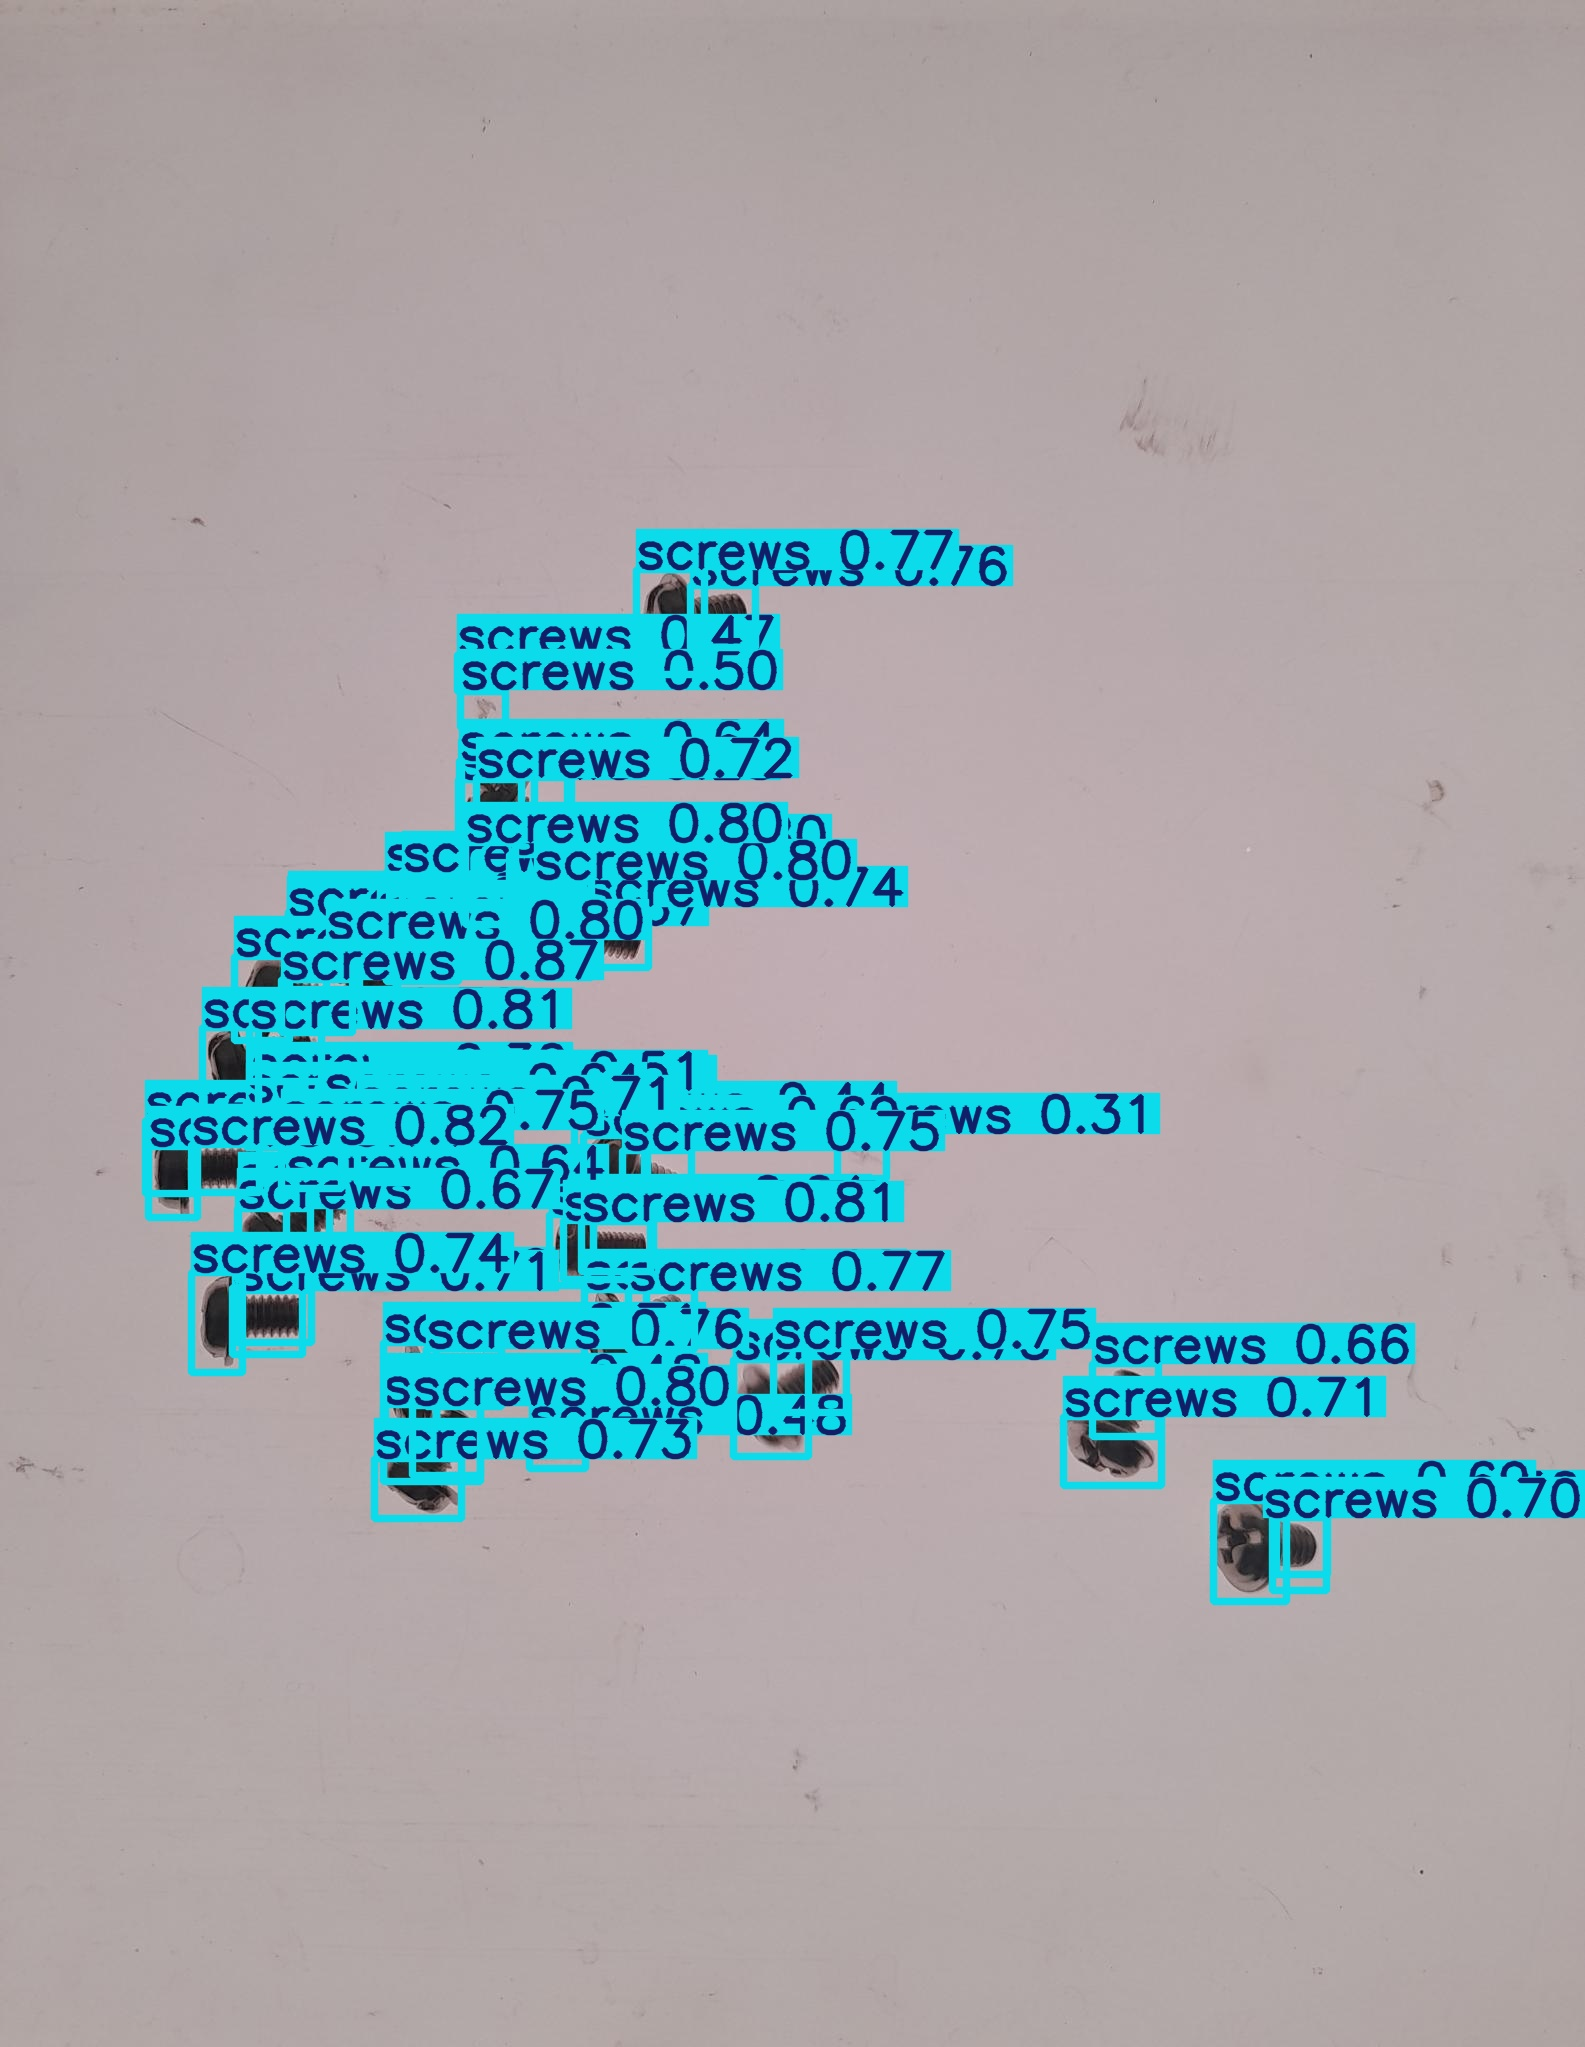



📌 20240713_193659_jpg.rf.02a0177702c96c7f38d1028732e57356.jpg ➡️ 10 objects


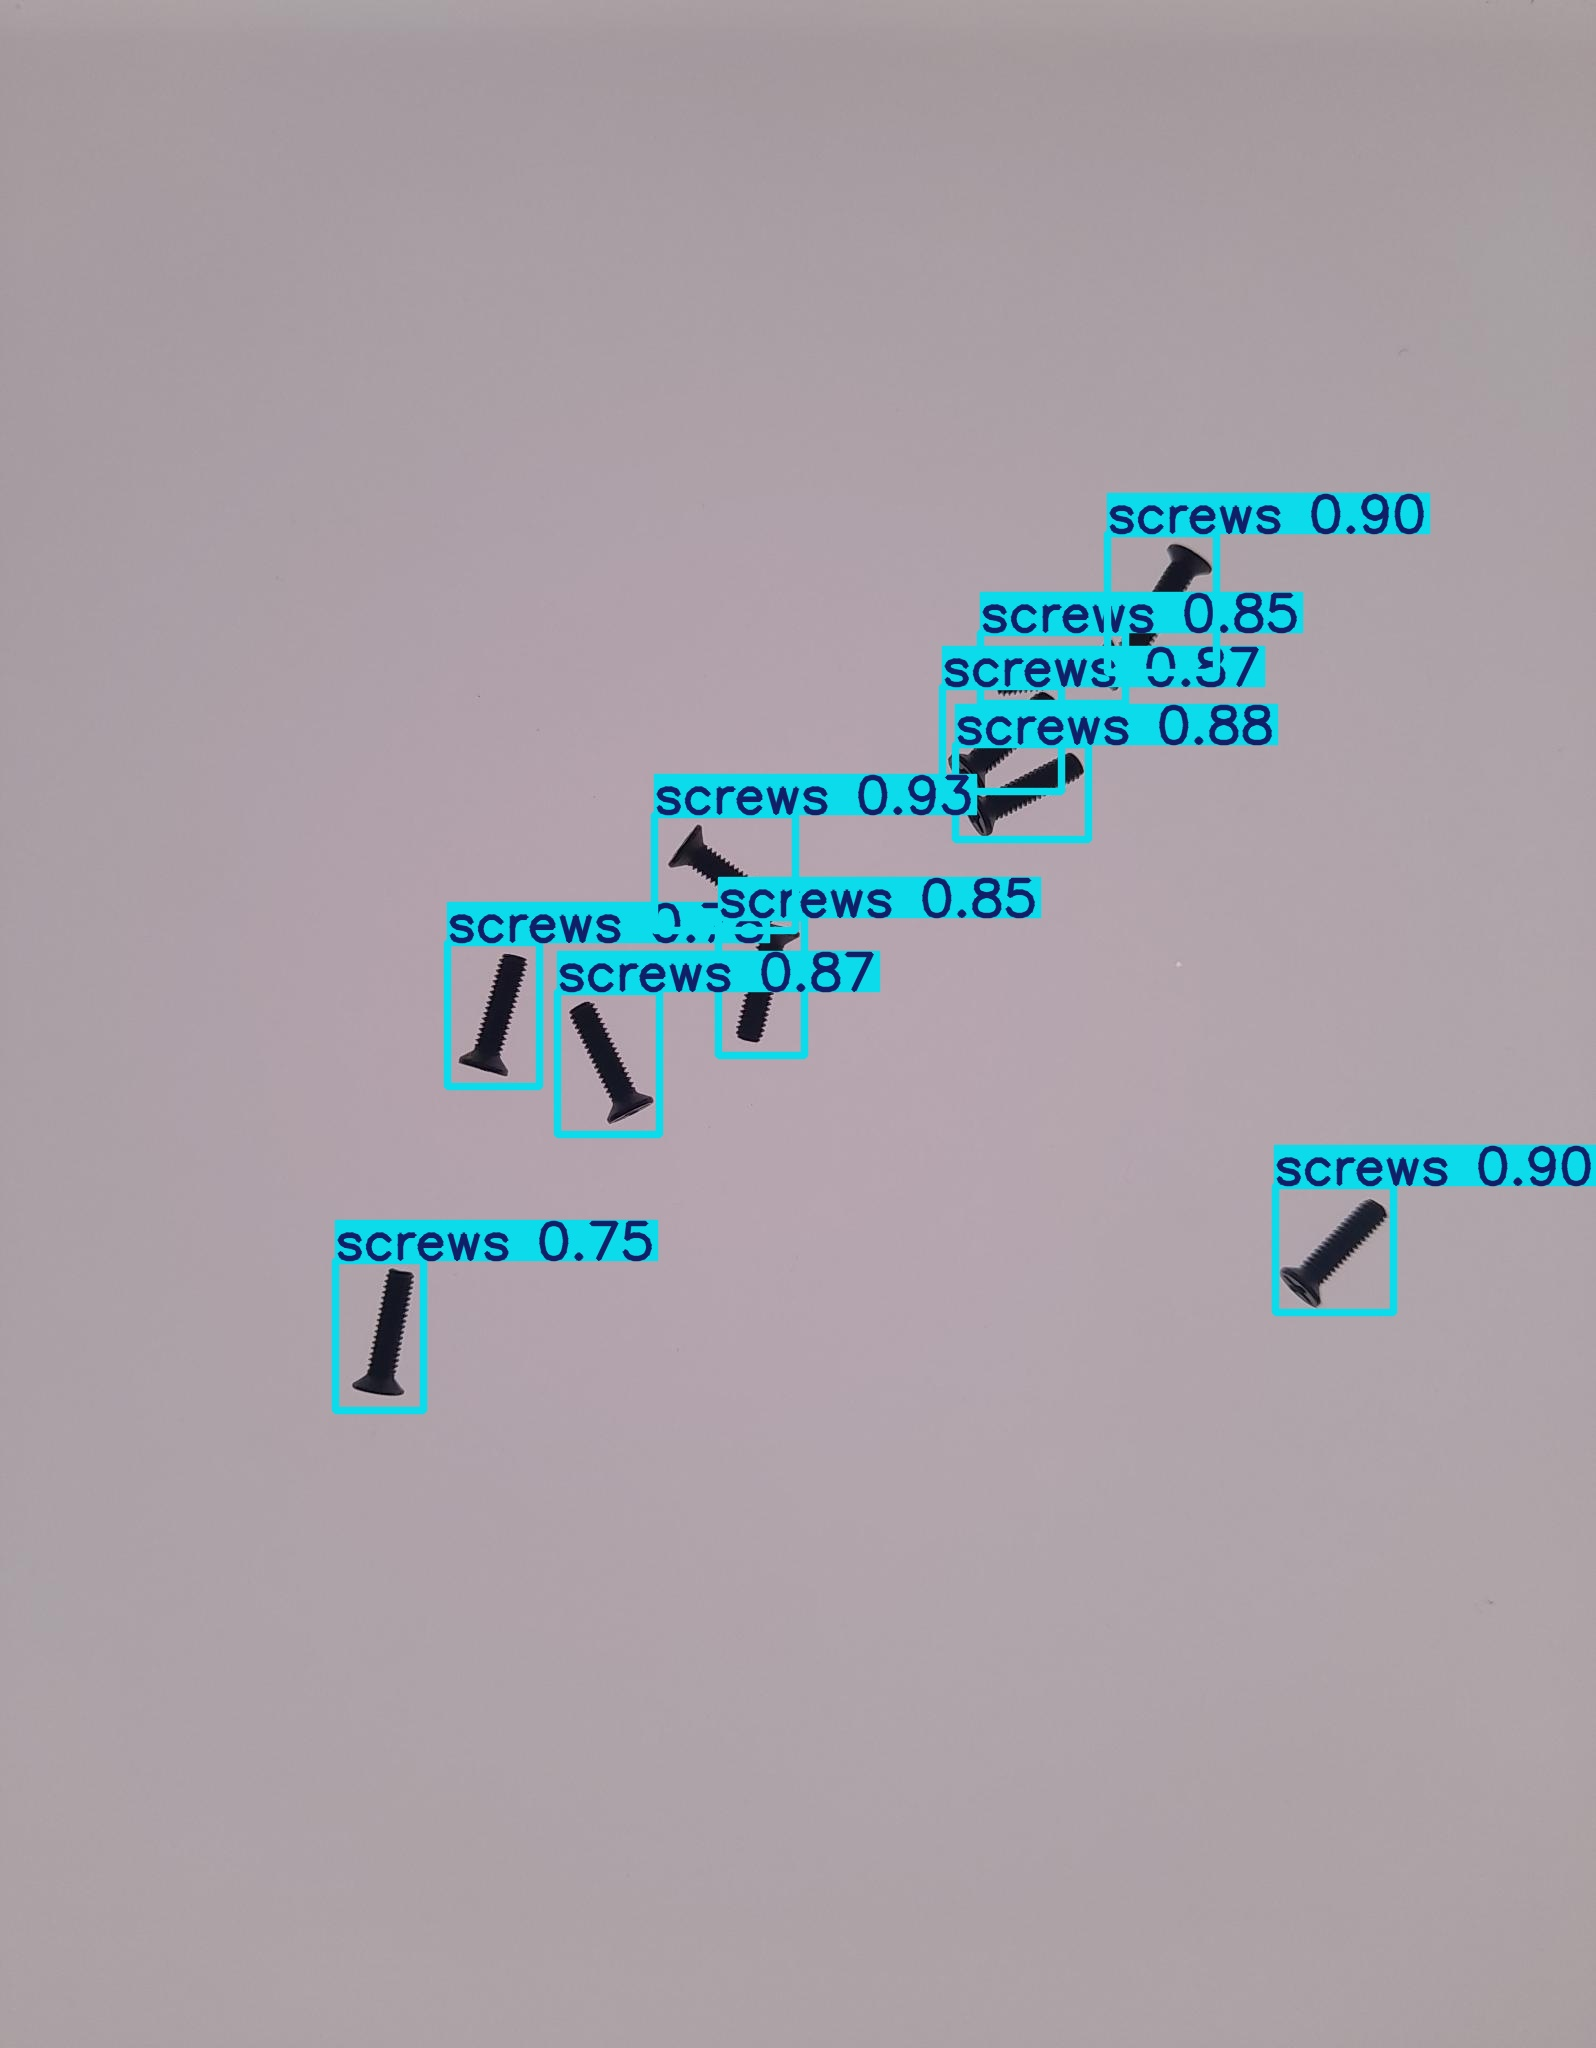



📌 img2_jpg.rf.ffe9424466766a75e29f42b4f01618a5.jpg ➡️ 43 objects


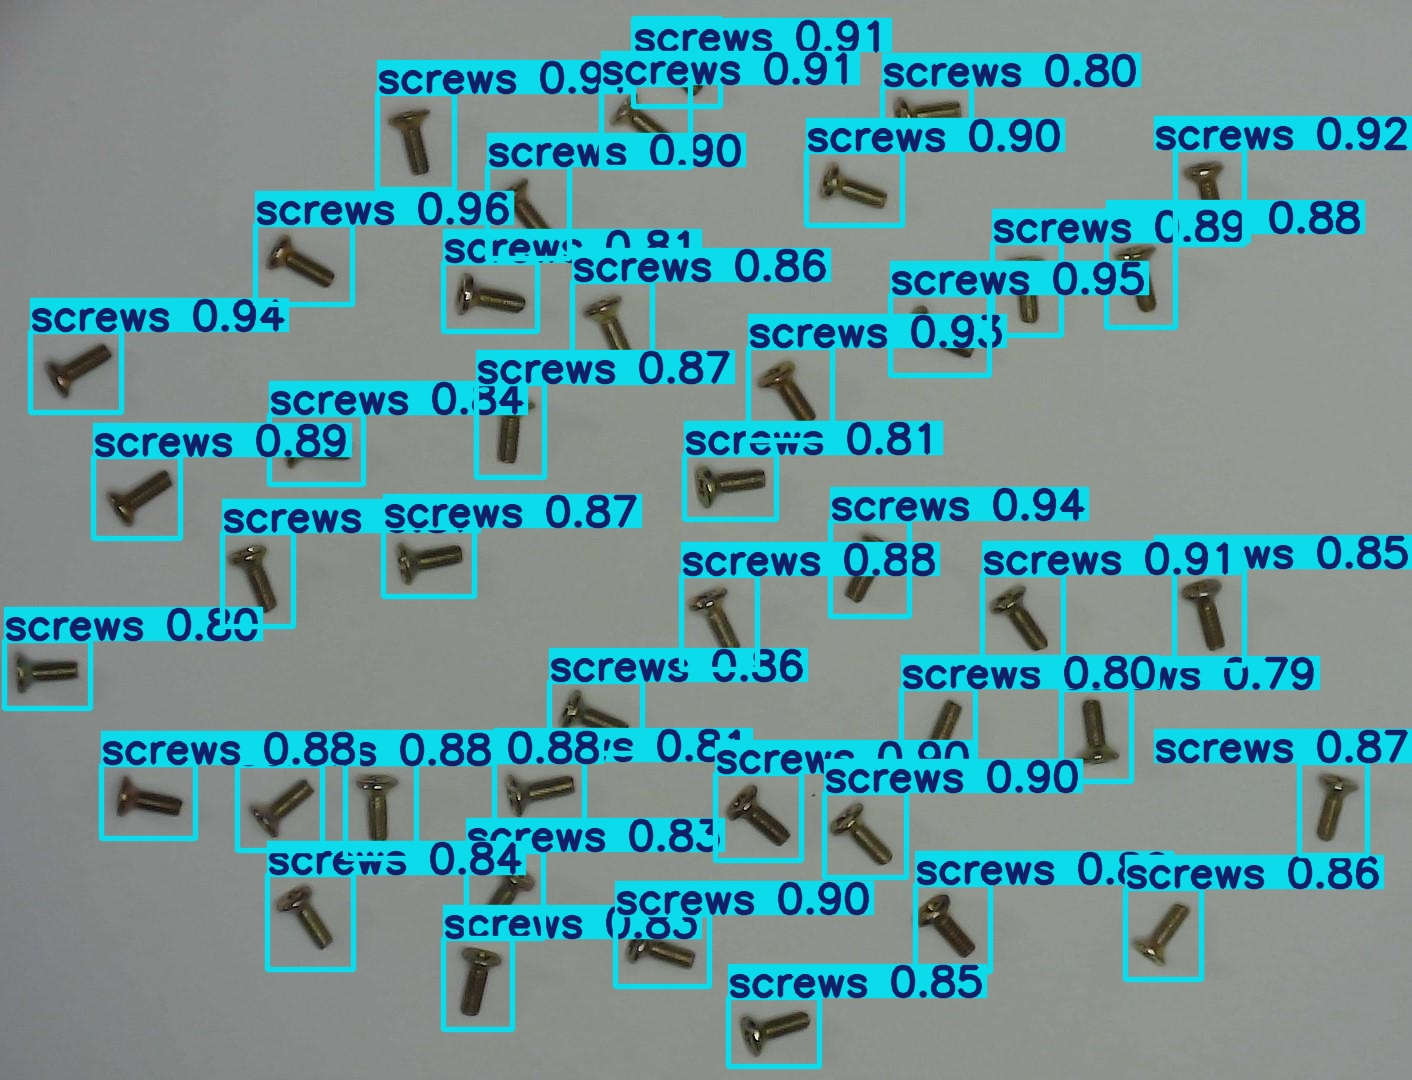



📌 20240713_192951_jpg.rf.7f0135cef9a1b5e5c346b8f96ea91654.jpg ➡️ 66 objects


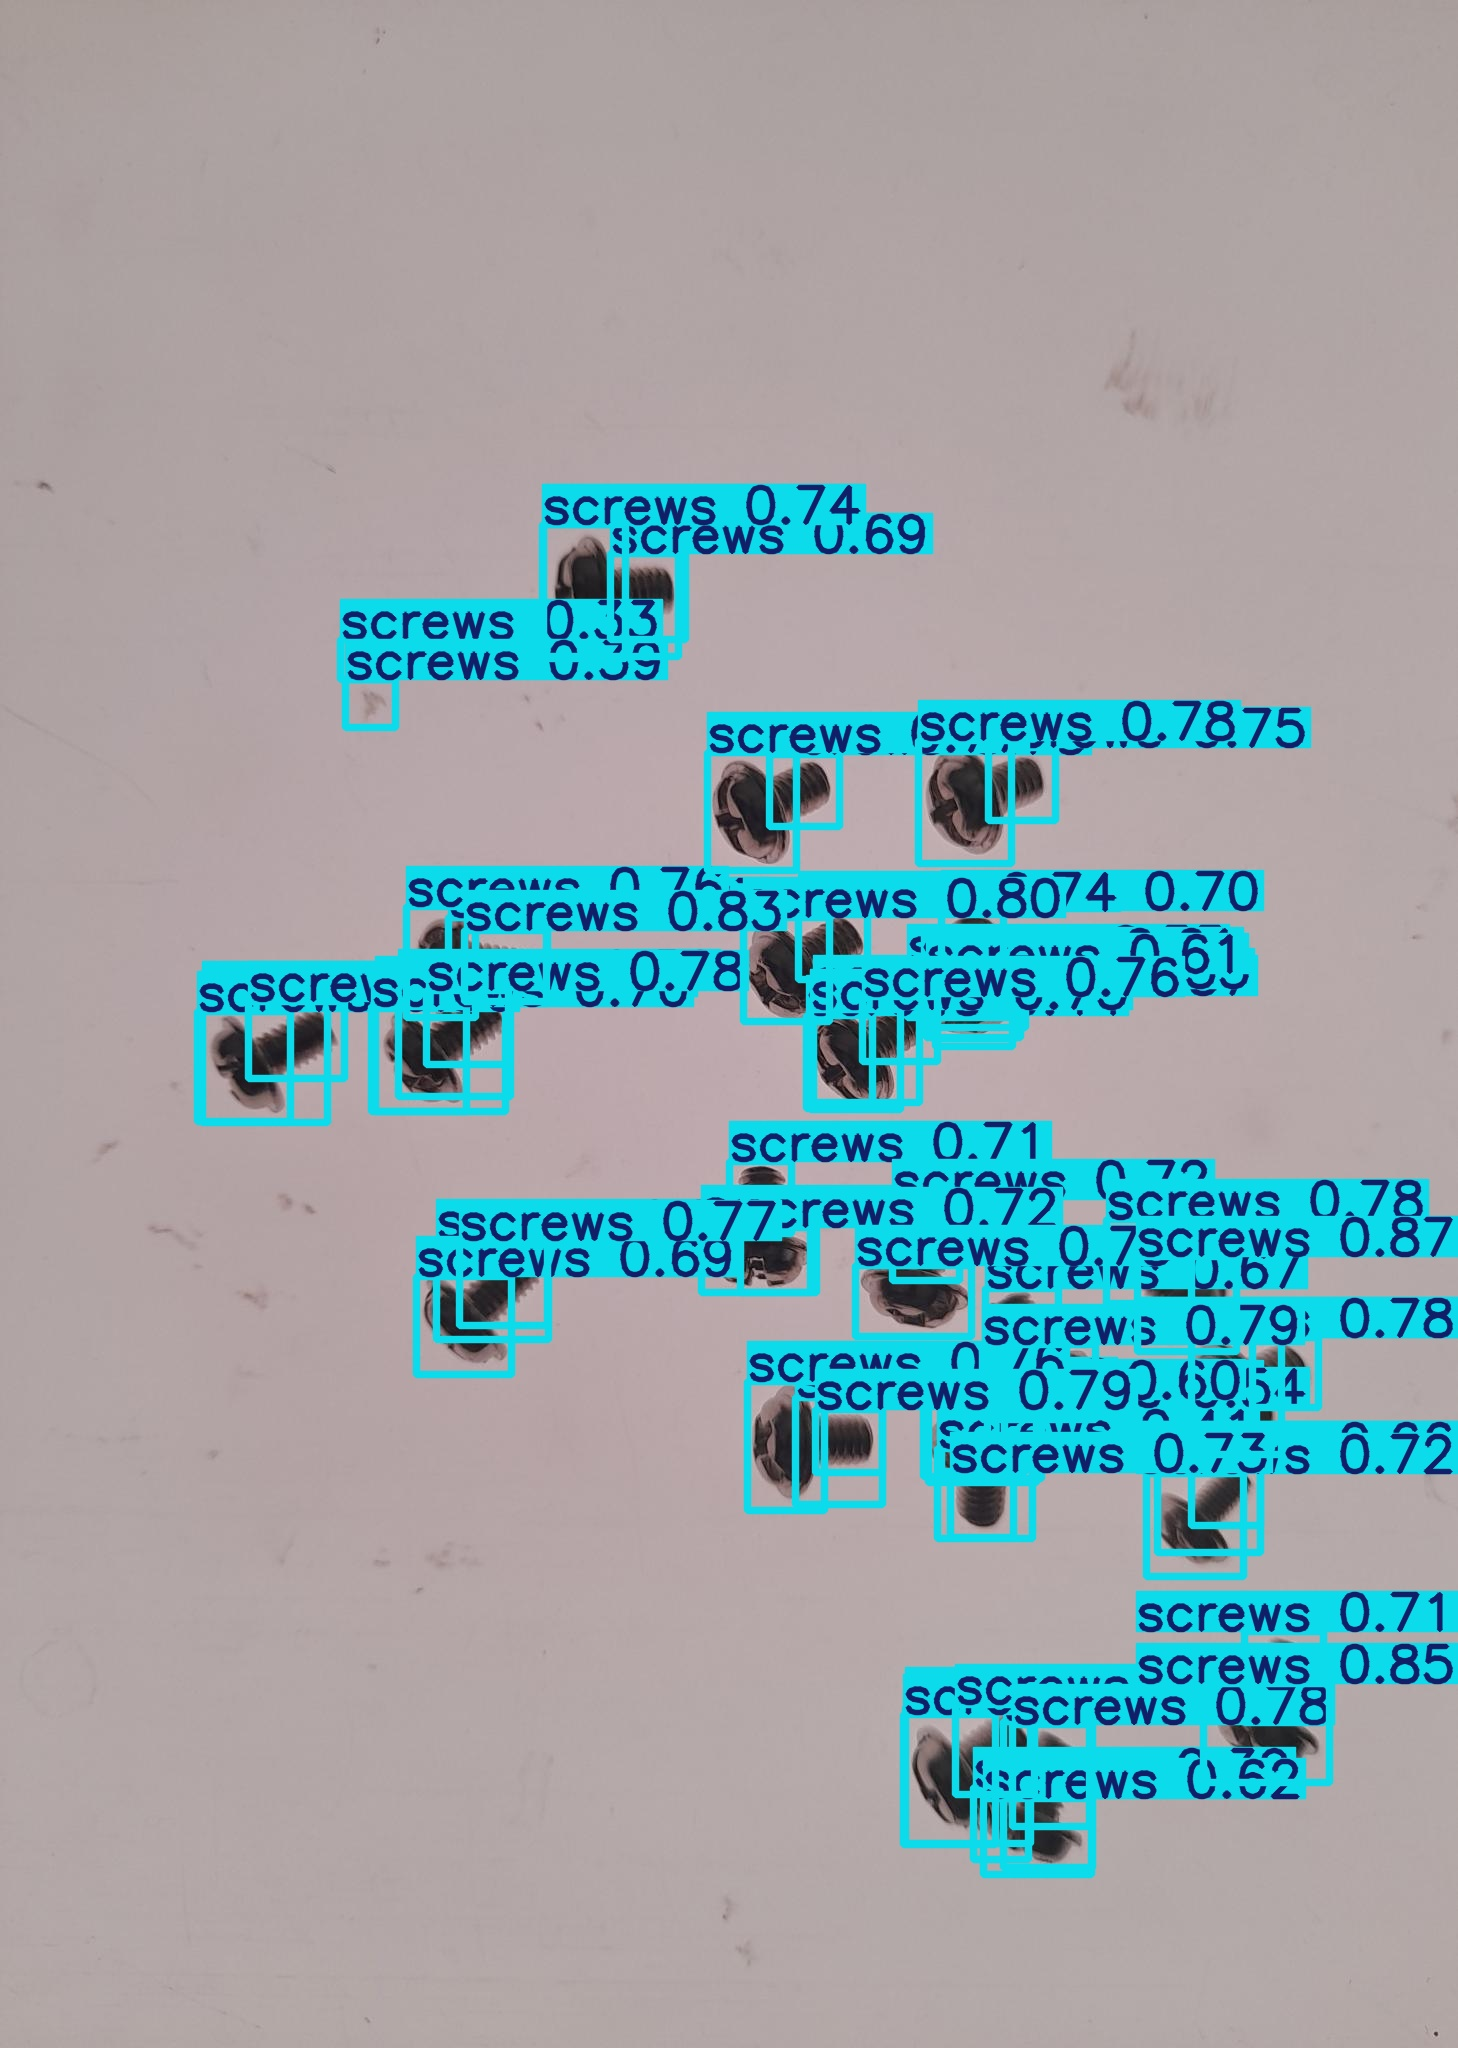



📌 img3_jpg.rf.b5f300570127bea33e1285556b146163.jpg ➡️ 43 objects


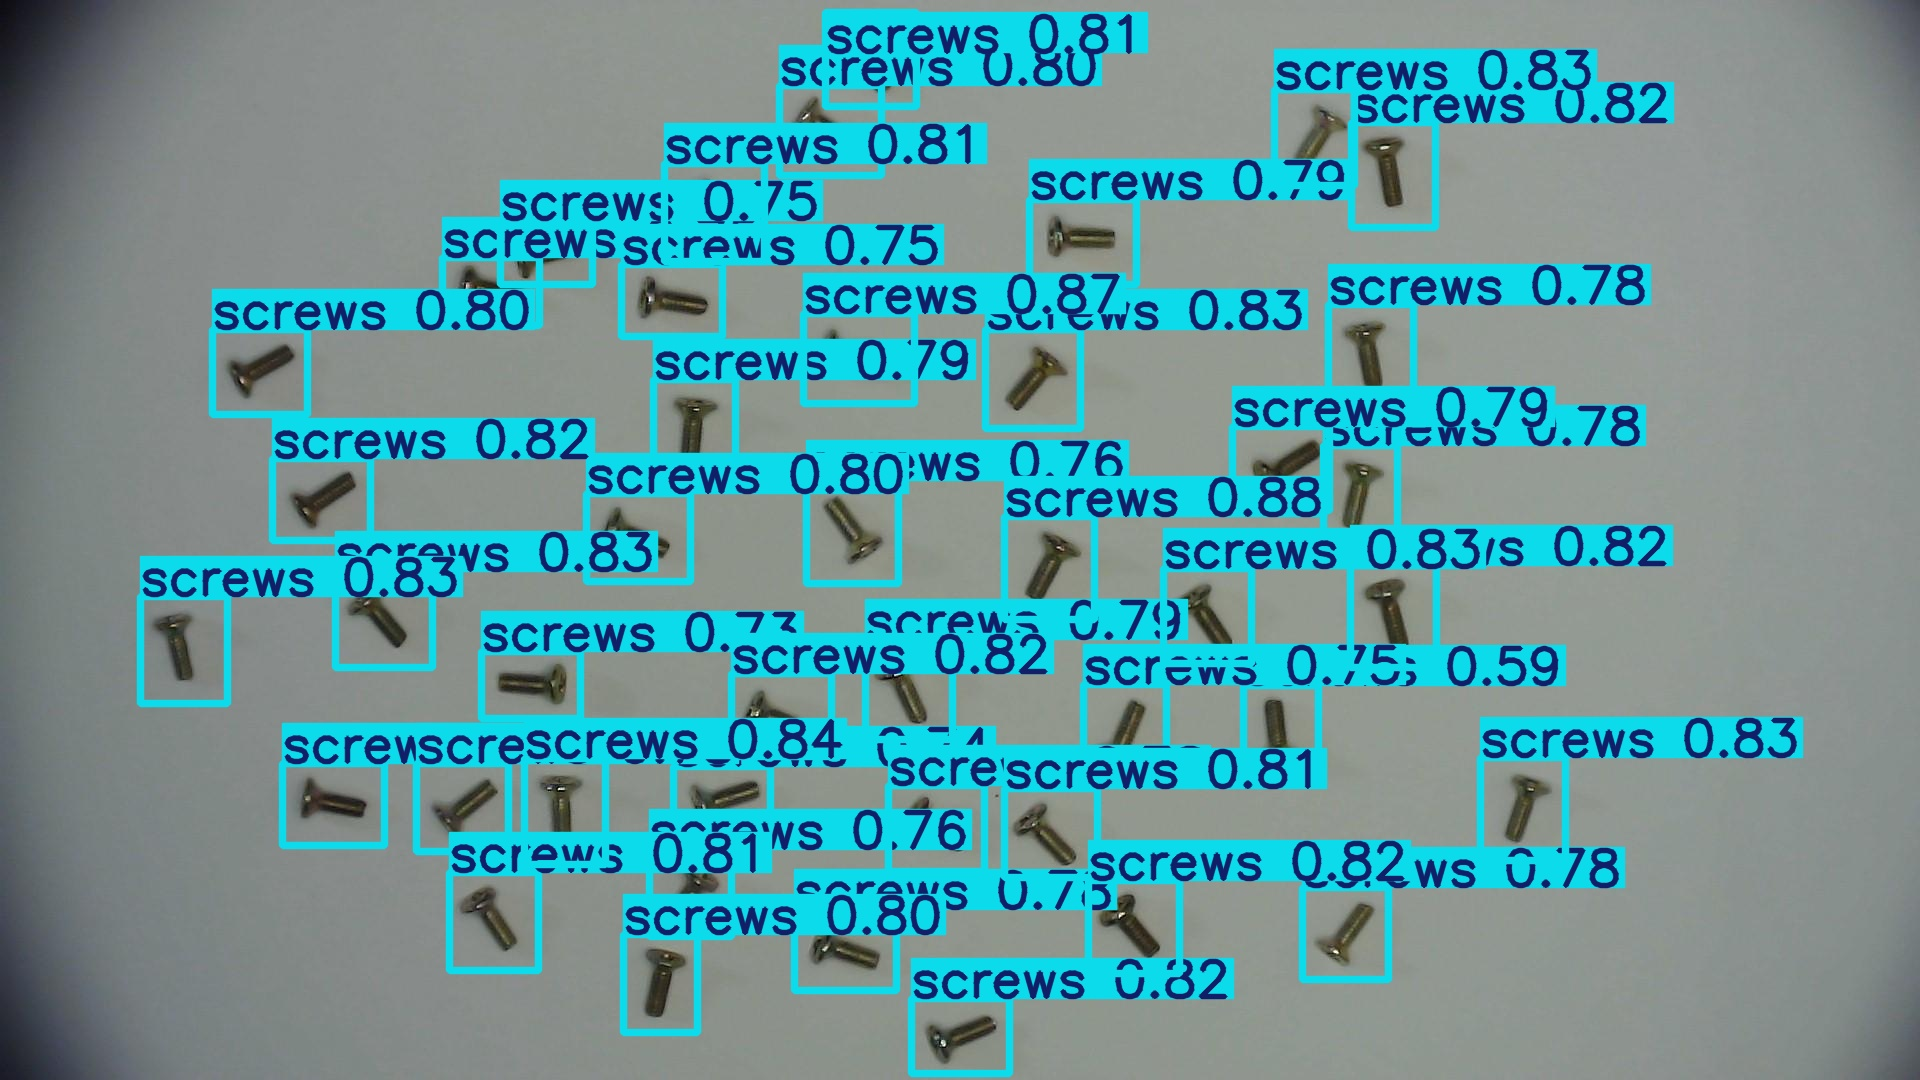



Total number of objects detected in all images: 227


In [27]:
import os
import glob
from IPython.display import Image, display


base_path = '/content/runs/detect/'
subfolders = [os.path.join(base_path, d) for d in os.listdir(base_path)
              if os.path.isdir(os.path.join(base_path, d)) and d.startswith('predict2')]

latest_folder = max(subfolders, key=os.path.getmtime)
print("Latest prediction folder:", latest_folder)


labels_path = os.path.join(latest_folder, 'labels')
print("Labels path:", labels_path)


total_objects = 0


image_paths = glob.glob(os.path.join(latest_folder, '*.jpg'))

print("\n Showing predicted images with object counts:")

for image_path in image_paths:

    base_name = os.path.splitext(os.path.basename(image_path))[0]
    label_file = os.path.join(labels_path, f"{base_name}.txt")

    if os.path.exists(label_file):
        with open(label_file, 'r') as f:
            num_objects = len(f.readlines())
    else:
        num_objects = 0

    total_objects += num_objects

    print(f"📌 {os.path.basename(image_path)} ➡️ {num_objects} objects")
    display(Image(filename=image_path, width=600))
    print("\n")

print(f"Total number of objects detected in all images: {total_objects}")
